## Dataset
### df_mono : pour stocker dataset de fichier csv qui contient mono langue
### df_multi : pour stocker dataset de fichier csv qui contient multi langue

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import fasttext
import re
from pathlib import Path

In [2]:
import os

print(os.listdir("../data/raw"))

['final1.csv', 'mono-langue.csv', 'multilingual_dataset.csv']


In [3]:
# 1. Chargement des deux datasets
df_mono = pd.read_csv("../data/raw/mono-langue.csv")
df_multi = pd.read_csv("../data/raw/multilingual_dataset.csv")


In [4]:
print("Mono langue")
print(f"Columns :{df_mono.columns}")
print(f"Shape :{df_mono.shape}")
print(f"Statistiques :{df_mono.describe()}")

Mono langue
Columns :Index(['review_id', 'text', 'rating', 'sentiment', 'product_category'], dtype='str')
Shape :(500, 5)
Statistiques :        review_id      rating
count  500.000000  500.000000
mean   250.500000    2.936000
std    144.481833    1.245394
min      1.000000    1.000000
25%    125.750000    2.000000
50%    250.500000    3.000000
75%    375.250000    4.000000
max    500.000000    5.000000


In [5]:
print("Multi langue")
print(f"Columns :{df_multi.columns}")
print(f"Shape :{df_multi.shape}")
print(f"Statistiques :{df_multi.describe()}")

Multi langue
Columns :Index(['review_id', 'text', 'language', 'rating', 'sentiment',
       'product_category'],
      dtype='str')
Shape :(4500, 6)
Statistiques :            rating
count  4500.000000
mean      3.030444
std       1.455636
min       1.000000
25%       2.000000
50%       3.000000
75%       5.000000
max       5.000000


In [6]:
df_mono.head(10)

,review_id,text,rating,sentiment,product_category
0,1,Great value for money,4,positive,fashion
1,2,"I love it, will definitely buy again",5,positive,home
2,3,Works perfectly and arrived quickly,5,positive,home
3,4,Decent quality for the price,3,neutral,fashion
4,5,"Terrible product, broke after one use",1,negative,home
5,6,It works as expected,3,neutral,home
6,7,Decent quality for the price,3,neutral,electronics
7,8,Not bad but not great either,3,neutral,home
8,9,Very disappointed with the quality,2,negative,electronics
9,10,Decent quality for the price,3,neutral,fashion


In [7]:
df_multi.head(10)

,review_id,text,language,rating,sentiment,product_category
0,63005481_rev_3,لماذا تتوقف المقاومة وتتراجع أثناء الطهي؟ أجهز...,arabic,4.0,positive,"Maison, cuisine & bureau"
1,mpg1544888_rev_4,ويتعين عليّ ربط جهاز استقبال خارجي,arabic,3.0,neutral,TV & HIGH TECH
2,mpg915615_rev_4,منتج جيد جداً ، مرضي جداً,arabic,5.0,positive,TV & HIGH TECH
3,65589111_rev_4,سوء الجودة,arabic,1.0,negative,Sports & Loisirs
4,mpg1447127_rev_3,منتج ممتاز يعمل بشكل مثالي، يتم تسليمها في الو...,arabic,5.0,positive,"Maison, cuisine & bureau"
5,mpg1539036_rev_4,أداة جيدة بشكل عام، ولكن يوتيوب خطأ ويحتاج إلى...,arabic,3.0,neutral,TV & HIGH TECH
6,65661061_rev_5,كما هو موضح، تقرير جودة الأسعار,arabic,5.0,positive,Sports & Loisirs
7,34408767_rev_3,جودة جيدة جداً / قوية جداً / تسليم سريع جداً.,arabic,5.0,positive,"Maison, cuisine & bureau"
8,67154065_rev_3,أنا أحبك,arabic,5.0,positive,TV & HIGH TECH
9,67489671_rev_4,أجهزة ممتازة، وأوصي بتسليم السرعة السريعة في ا...,arabic,5.0,positive,"Maison, cuisine & bureau"


## 1. Distribution des sentiments

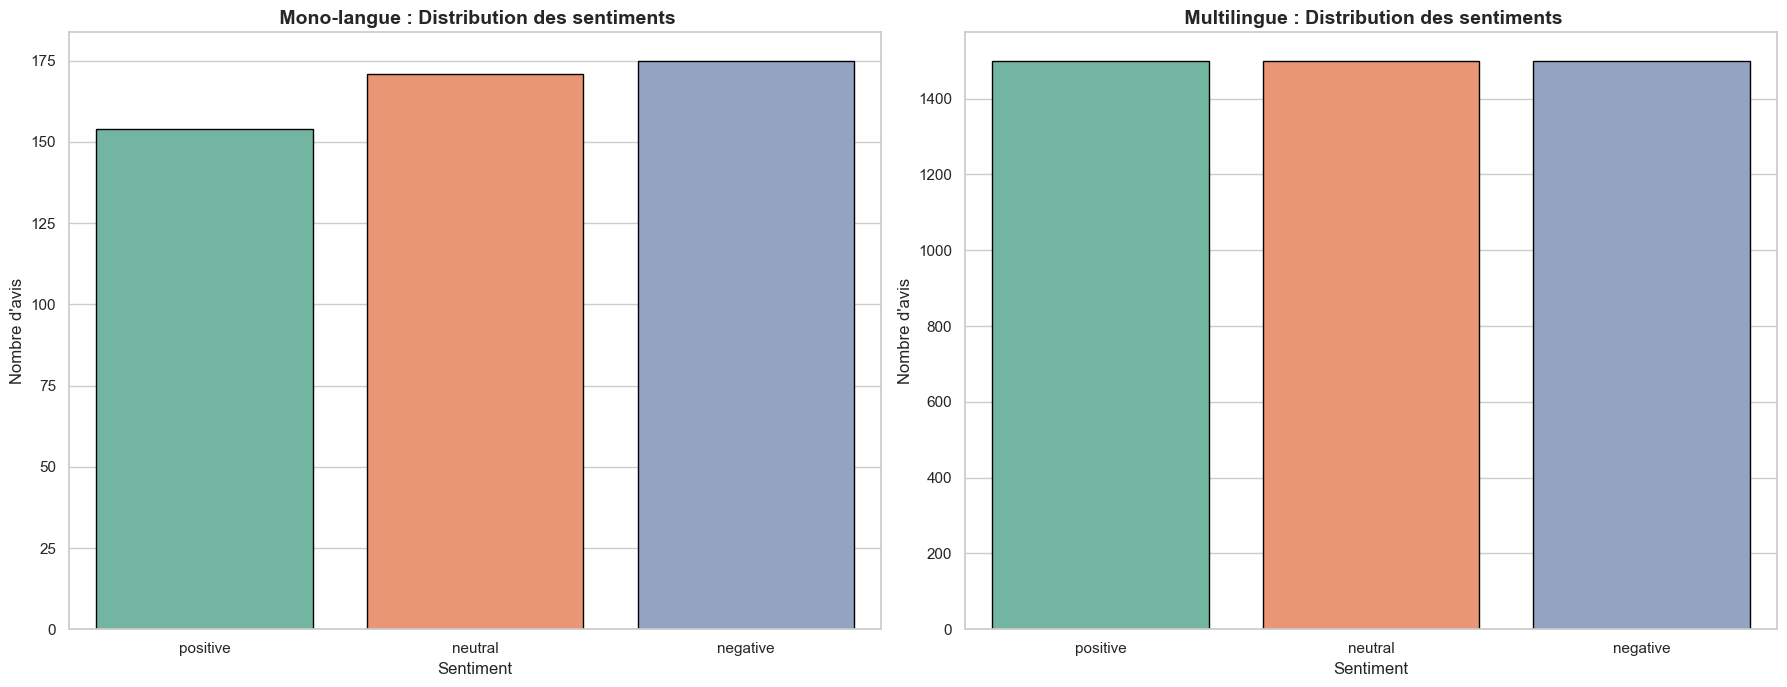

 Mono-langue — Comptes par sentiment :
sentiment
negative    175
neutral     171
positive    154
Name: count, dtype: int64

 Multilingue — Comptes par sentiment :
sentiment
negative    1500
neutral     1500
positive    1500
Name: count, dtype: int64


In [28]:
# 2. Configuration visuelle
sns.set_theme(style="whitegrid")
sentiment_order = ['positive', 'neutral', 'negative']  # ordre logique
plt.rcParams['figure.figsize'] = [18, 7]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# 3. Graphique 1 : df_mono
plt.subplot(1, 2, 1)
order_mono = [s for s in sentiment_order if s in df_mono['sentiment'].values]
if not order_mono:
    order_mono = sorted(df_mono['sentiment'].dropna().unique())

ax_mono = sns.countplot(
    data=df_mono,
    x='sentiment',
    order=order_mono,
    hue='sentiment',
    hue_order=order_mono,
    palette='Set2',
    edgecolor='black'
 )
if ax_mono.legend_:
    ax_mono.legend_.remove()
plt.title(" Mono-langue : Distribution des sentiments", fontweight='bold', fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)
plt.xticks(rotation=0, fontsize=11)

# 4. Graphique 2 : df_multi
plt.subplot(1, 2, 2)
order_multi = [s for s in sentiment_order if s in df_multi['sentiment'].values]
if not order_multi:
    order_multi = sorted(df_multi['sentiment'].dropna().unique())

ax_multi = sns.countplot(
    data=df_multi,
    x='sentiment',
    order=order_multi,
    hue='sentiment',
    hue_order=order_multi,
    palette='Set2',
    edgecolor='black'
 )
if ax_multi.legend_:
    ax_multi.legend_.remove()
plt.title(" Multilingue : Distribution des sentiments", fontweight='bold', fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)
plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# Bonus : Affichage des comptes bruts pour verification
print(" Mono-langue — Comptes par sentiment :")
print(df_mono['sentiment'].value_counts().sort_index())
print("\n Multilingue — Comptes par sentiment :")
print(df_multi['sentiment'].value_counts().sort_index())

### 2. Distribution des langues (Dataset Multilingual)

Langues detectees : <StringArray>
['arabic', 'darija_arabizi', 'darija_arabic', 'english', 'french']
Length: 5, dtype: str


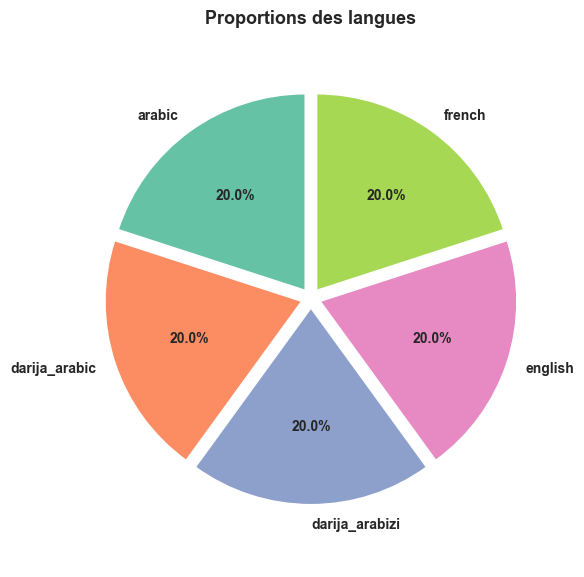


Resume — Distribution des langues :
- arabic   :   900 avis  ->  20.00%
- darija_arabic :   900 avis  ->  20.00%
- darija_arabizi :   900 avis  ->  20.00%
- english  :   900 avis  ->  20.00%
- french   :   900 avis  ->  20.00%


In [ ]:
# 2. Verification des langues presentes
print("Langues detectees :", df_multi['language'].dropna().unique())

# 3. Preparation des donnees
lang_counts = df_multi['language'].value_counts()
# Ordre souhaite (ajustable)
lang_order = ['EN', 'FR', 'DAR']
# Garder uniquement les langues presentes
lang_order = [l for l in lang_order if l in lang_counts.index]
# Si ordre vide -> utiliser les valeurs triees
if not lang_order:
    lang_order = sorted(lang_counts.index)

# 5. Graphique 2 (Optionnel) : Pie Chart pour visualiser les proportions
plt.figure(figsize=(10, 8))
colors = plt.cm.Set2(range(len(lang_order)))
plt.pie(lang_counts.loc[lang_order], 
        labels=lang_counts.loc[lang_order].index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'},
        explode=[0.05]*len(lang_order))  # leger detachement pour lisibilite
plt.title("Proportions des langues", fontweight='bold', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Bonus : Resume statistique
print("\nResume — Distribution des langues :")
for lang in lang_order:
    count = lang_counts[lang]
    total = lang_counts.sum()
    pct = (count / total) * 100
    print(f"- {lang:8s} : {count:5d} avis  ->  {pct:5.2f}%")

### 3. Distribution de la longueur des textes

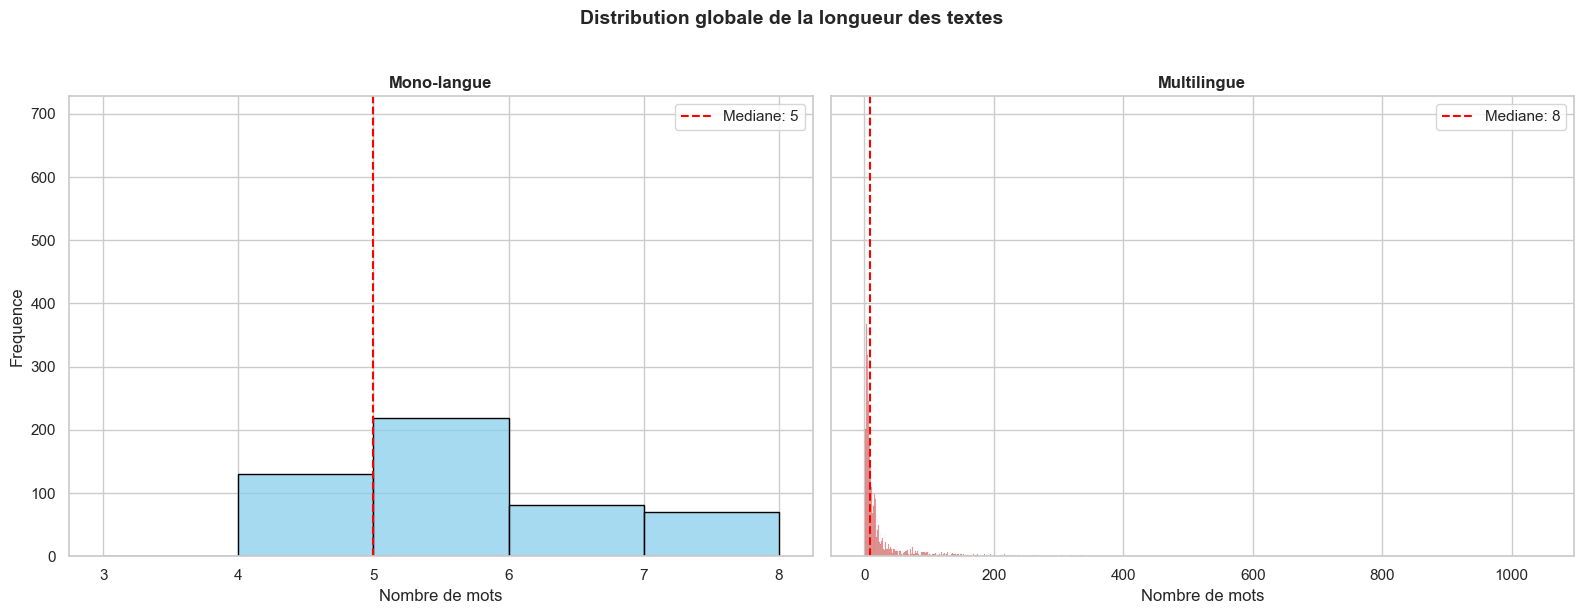

df_multi — Langues a tracer : ['arabic', 'darija_arabizi', 'darija_arabic', 'english', 'french']


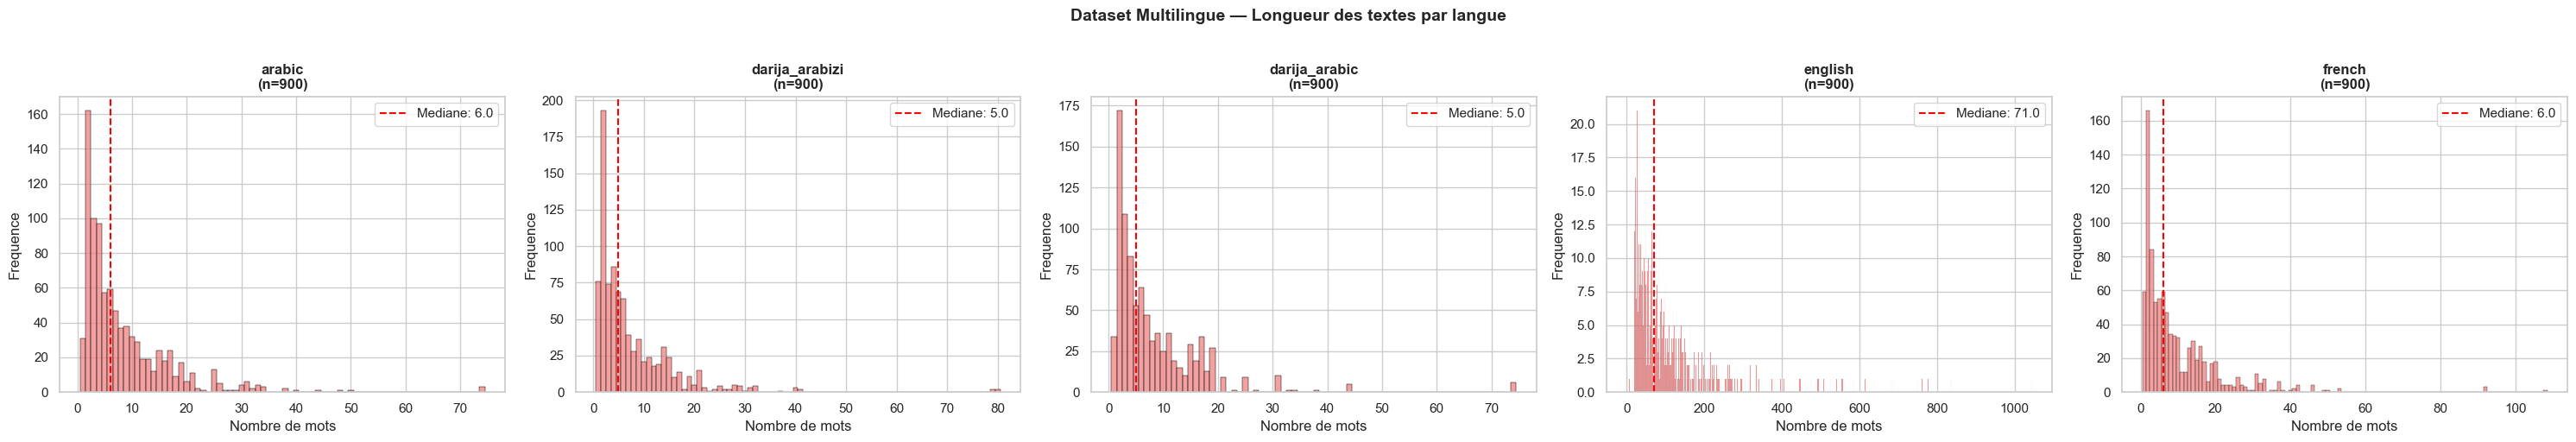


RESUME — Longueur moyenne des textes par langue

 df_mono :
  Total : 500 avis | Moyenne : 5.18 mots

 df_multi :
  arabic   :   900 avis | Moyenne :  8.35 mots | Mediane : 6 mots
  darija_arabizi :   900 avis | Moyenne :  7.53 mots | Mediane : 5 mots
  darija_arabic :   900 avis | Moyenne :  8.23 mots | Mediane : 5 mots
  english  :   900 avis | Moyenne : 104.07 mots | Mediane : 71 mots
  french   :   900 avis | Moyenne :  9.68 mots | Mediane : 6 mots


In [ ]:
# =============================================================================
# 1. FONCTION : Calculer la longueur du texte
# =============================================================================
def compute_text_length(df, text_col='text', method='words'):
    df = df.copy()
    df[text_col] = df[text_col].fillna('').astype(str)
    if method == 'words':
        df['length'] = df[text_col].str.split().str.len()
    elif method == 'chars':
        df['length'] = df[text_col].str.replace(' ', '', regex=False).str.len()
    return df


# =============================================================================
# 2. CALCULER LA LONGUEUR
# =============================================================================
df_mono = compute_text_length(df_mono, method='words')
df_multi = compute_text_length(df_multi, method='words')

# =============================================================================
# 3 bis. GRAPHIQUE GLOBAL : Mono vs Multilingue
# =============================================================================
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Mono-langue
sns.histplot(df_mono, x='length', bins=range(int(df_mono['length'].min()) - 1, int(df_mono['length'].max()) + 2),
             color='skyblue', edgecolor='black', ax=ax_left, linewidth=1.5)
ax_left.axvline(df_mono['length'].median(), color='red', linestyle='--', linewidth=2.5,
                label=f"Mediane: {df_mono['length'].median():.0f}")
ax_left.set_title("Mono-langue", fontweight='bold', fontsize=14)
ax_left.set_xlabel("Nombre de mots", fontsize=12)
ax_left.set_ylabel("Frequence", fontsize=12)
ax_left.legend(fontsize=11)

# Multilingue global
sns.histplot(df_multi, x='length', bins=range(int(df_multi['length'].min()) - 1, int(df_multi['length'].max()) + 2),
             color='lightcoral', edgecolor='black', ax=ax_right, linewidth=1.5)
ax_right.axvline(df_multi['length'].median(), color='red', linestyle='--', linewidth=2.5,
                 label=f"Mediane: {df_multi['length'].median():.0f}")
ax_right.set_title("Multilingue", fontweight='bold', fontsize=14)
ax_right.set_xlabel("Nombre de mots", fontsize=12)
ax_right.set_ylabel("Frequence", fontsize=12)
ax_right.legend(fontsize=11)

plt.suptitle("Distribution globale de la longueur des textes", fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =============================================================================
# 4. GRAPHIQUE 2 : df_multi (comparaison par langue)
# =============================================================================
# Langues a afficher
langues_multi = df_multi['language'].dropna().unique()
langues_dispo = [l for l in langues_multi if l in df_multi['language'].values]
print(f"df_multi — Langues a tracer : {langues_dispo}")

# Creer les sous-graphiques
fig2, axes = plt.subplots(1, len(langues_dispo), figsize=(8 * len(langues_dispo), 6))
if len(langues_dispo) == 1:
    axes = [axes]

for i, lang in enumerate(langues_dispo):
    df_lang = df_multi[df_multi['language'] == lang]
    
    min_val = int(df_lang['length'].min())
    max_val = int(df_lang['length'].max())
    bins = np.arange(min_val - 0.5, max_val + 1.5, 1)
    
    sns.histplot(data=df_lang, x='length', bins=bins, color='lightcoral', 
                 edgecolor='black', stat='count', ax=axes[i], linewidth=1.5)
    
    median = df_lang['length'].median()
    axes[i].axvline(median, color='red', linestyle='--', linewidth=2.5, label=f'Mediane: {median}')
    
    axes[i].set_title(f"{lang}\n(n={len(df_lang)})", fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Nombre de mots', fontsize=11)
    axes[i].set_ylabel('Frequence', fontsize=11)
    axes[i].legend(fontsize=10)

plt.suptitle("Dataset Multilingue — Longueur des textes par langue", fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =============================================================================
# 5 Resume statistique
# =============================================================================
print("\n" + "="*60)
print("RESUME — Longueur moyenne des textes par langue")
print("="*60)

print("\n df_mono :")
if 'language' in df_mono.columns:
    print(df_mono.groupby('language')['length'].agg(['count', 'mean', 'median']).round(2))
else:
    print(f"  Total : {len(df_mono)} avis | Moyenne : {df_mono['length'].mean():.2f} mots")

print("\n df_multi :")
for lang in langues_dispo:
    df_lang = df_multi[df_multi['language'] == lang]
    print(f"  {lang:8s} : {len(df_lang):5d} avis | Moyenne : {df_lang['length'].mean():5.2f} mots | Mediane : {df_lang['length'].median():.0f} mots")

## 4. Distribution des catégories produits

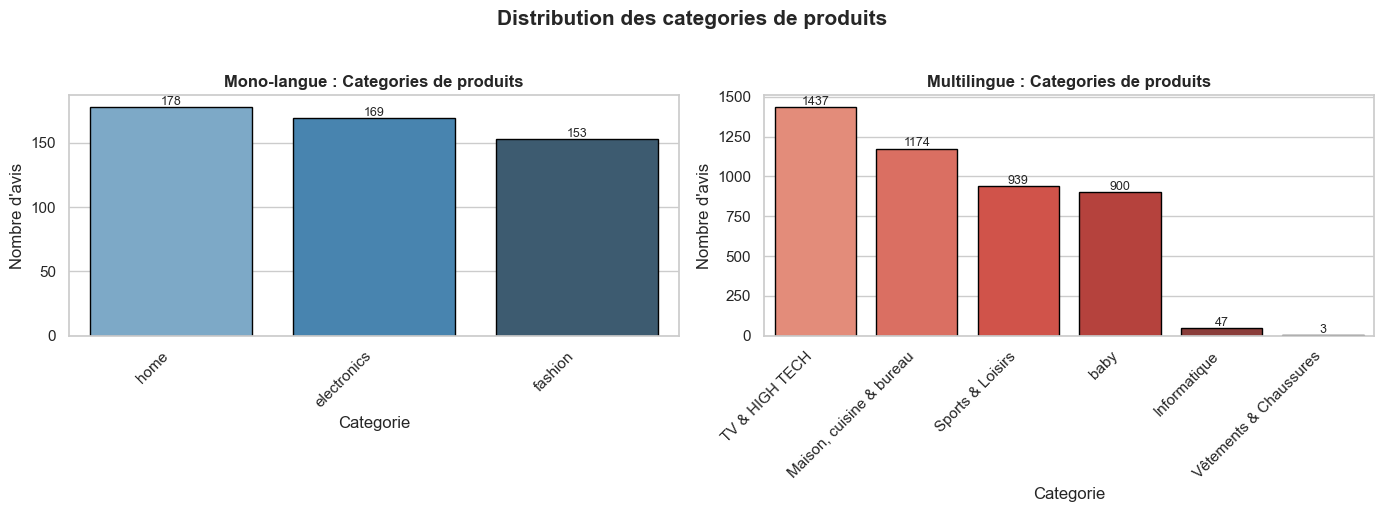


df_mono — Top categories :
product_category
home           178
electronics    169
fashion        153
Name: count, dtype: int64

df_multi — Top categories :
product_category
TV & HIGH TECH              1437
Maison, cuisine & bureau    1174
Sports & Loisirs             939
baby                         900
Informatique                  47
Vêtements & Chaussures         3
Name: count, dtype: int64


In [ ]:
# Configuration visuelle
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [18, 7]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# =============================================================================
# -> GRAPHIQUE 1 : df_mono
# =============================================================================
plt.subplot(1, 2, 1)

# Compter les categories (triees par frequence decroissante)
cat_mono = df_mono['product_category'].dropna().value_counts().sort_values(ascending=False)

# Bar chart
ax_mono = sns.barplot(
    x=cat_mono.index,
    y=cat_mono.values,
    hue=cat_mono.index,
    palette='Blues_d',
    edgecolor='black',
    dodge=False,
    linewidth=1.5
 )
if ax_mono.legend_:
    ax_mono.legend_.remove()

# Ajouter les valeurs au-dessus des barres
for i, v in enumerate(cat_mono.values):
    plt.text(i, v + max(cat_mono.values)*0.01, str(v), ha='center', fontsize=10, fontweight='bold')

plt.title("Mono-langue : Categories de produits", fontweight='bold', fontsize=14)
plt.xlabel("Categorie", fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()

# =============================================================================
# -> GRAPHIQUE 2 : df_multi
# =============================================================================
plt.subplot(1, 2, 2)

# Compter les categories
cat_multi = df_multi['product_category'].dropna().value_counts().sort_values(ascending=False)

# Bar chart
ax_multi = sns.barplot(
    x=cat_multi.index,
    y=cat_multi.values,
    hue=cat_multi.index,
    palette='Reds_d',
    edgecolor='black',
    dodge=False,
    linewidth=1.5
 )
if ax_multi.legend_:
    ax_multi.legend_.remove()

# Ajouter les valeurs au-dessus des barres
for i, v in enumerate(cat_multi.values):
    plt.text(i, v + max(cat_multi.values)*0.01, str(v), ha='center', fontsize=10, fontweight='bold')

plt.title("Multilingue : Categories de produits", fontweight='bold', fontsize=14)
plt.xlabel("Categorie", fontsize=12)
plt.ylabel("Nombre d'avis", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.tight_layout()

# =============================================================================
# -> AFFICHAGE + STATS
# =============================================================================
plt.suptitle("Distribution des categories de produits", fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Resume dans la console
print("\ndf_mono — Top categories :")
print(cat_mono.head(10))

print("\ndf_multi — Top categories :")
print(cat_multi.head(10))

Dropdown(description='Vue:', index=1, options=('Ratings', 'Sentiments', 'Langue'), style=DescriptionStyle(desc…

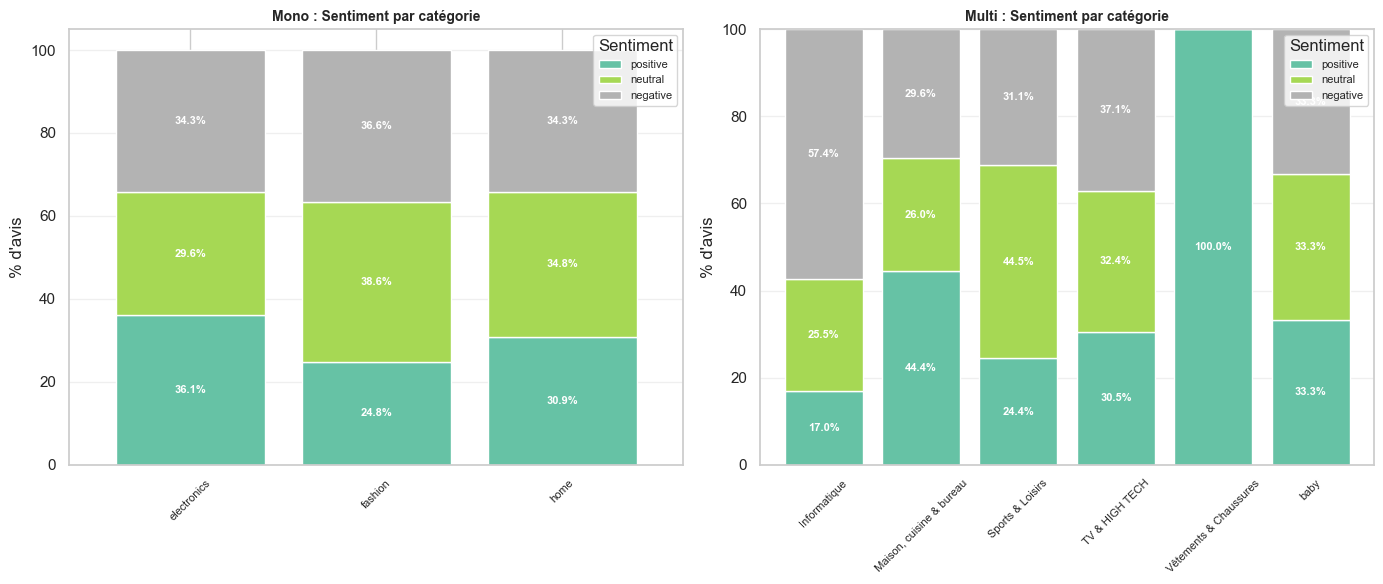

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, clear_output

# =============================================================================
# 1. FONCTIONS UTILITAIRES
# =============================================================================

def plot_stacked_sentiment(df, ax, title):
    """Trace un bar chart empile (en %) des sentiments par categorie avec pourcentages"""
    ct = pd.crosstab(df['product_category'], df['sentiment'], normalize='index') * 100
    order = ['positive', 'neutral', 'negative']
    cols = [c for c in order if c in ct.columns]
    ct = ct[cols]
    
    # Tracer le graphique empilé
    bars = ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', width=0.8, edgecolor='white', linewidth=1.5)
    
    # Ajouter les pourcentages sur chaque segment
    for i, (idx, row) in enumerate(ct.iterrows()):
        cumsum = 0
        for j, (col, value) in enumerate(row.items()):
            if value > 5:  # Afficher seulement si > 5% pour éviter la surcharge
                ax.text(i, cumsum + value/2, f'{value:.1f}%', 
                       ha='center', va='center', fontsize=10, fontweight='bold', color='white')
            cumsum += value
    
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('', fontsize=12)
    ax.set_ylabel('% d\'avis', fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.legend(title='Sentiment', fontsize=11, title_fontsize=11, loc='upper right')
    ax.grid(axis='y', alpha=0.3, linewidth=1.2)

# =============================================================================
# 2. INTERFACE NOTEBOOK SIMPLE
# =============================================================================

def afficher_ratings(df_mono, df_multi):
    """Affiche les boxplots des ratings"""
    df_combine = pd.concat([
        df_mono.assign(Type='Mono'),
        df_multi.assign(Type='Multi')
    ])
    fig, ax = plt.subplots(figsize=(18, 7))
    sns.boxplot(data=df_combine, x='product_category', y='rating', 
               hue='Type', ax=ax, palette='Set2', linewidth=2)
    ax.set_title('Notes par catégorie', fontweight='bold', fontsize=16)
    ax.set_ylabel('Note (1-5)', fontsize=12)
    ax.set_xlabel('', fontsize=12)
    ax.tick_params(axis='x', rotation=35, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.legend(fontsize=11, title_fontsize=12)
    plt.xticks(ha='right')
    plt.tight_layout()
    plt.show()

def afficher_sentiments(df_mono, df_multi):
    """Affiche les sentiments empilés avec pourcentages"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    plot_stacked_sentiment(df_mono, ax1, "Mono : Sentiment par catégorie")
    plot_stacked_sentiment(df_multi, ax2, "Multi : Sentiment par catégorie")
    plt.tight_layout()
    plt.show()

def afficher_langue(df_mono, df_multi):
    """Affiche la heatmap des langues"""
    fig, ax = plt.subplots(figsize=(12, 8))
    ct = pd.crosstab(df_multi['product_category'], df_multi['language'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=1.5,
               cbar_kws={'label': "Nombre d'avis"}, annot_kws={'fontsize': 11})
    ax.set_title('Multi : Langue x Catégorie', fontweight='bold', fontsize=16)
    ax.set_xlabel('Langue', fontsize=12)
    ax.set_ylabel('Catégorie', fontsize=12)
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()

# =============================================================================
# 3. WIDGET DE SELECTION
# =============================================================================

sns.set_theme(style="whitegrid")

dropdown = widgets.Dropdown(
    options=['Ratings', 'Sentiments', 'Langue'],
    value='Ratings',
    description='Vue:',
    style={'description_width': 'initial'}
)

def on_change(change):
    clear_output(wait=True)
    display(dropdown)
    
    if change['new'] == 'Ratings':
        afficher_ratings(df_mono, df_multi)
    elif change['new'] == 'Sentiments':
        afficher_sentiments(df_mono, df_multi)
    elif change['new'] == 'Langue':
        afficher_langue(df_mono, df_multi)

dropdown.observe(on_change, names='value')

# Afficher le menu et le premier graphique
display(dropdown)
afficher_ratings(df_mono, df_multi)

Analyse du code-switching en cours...


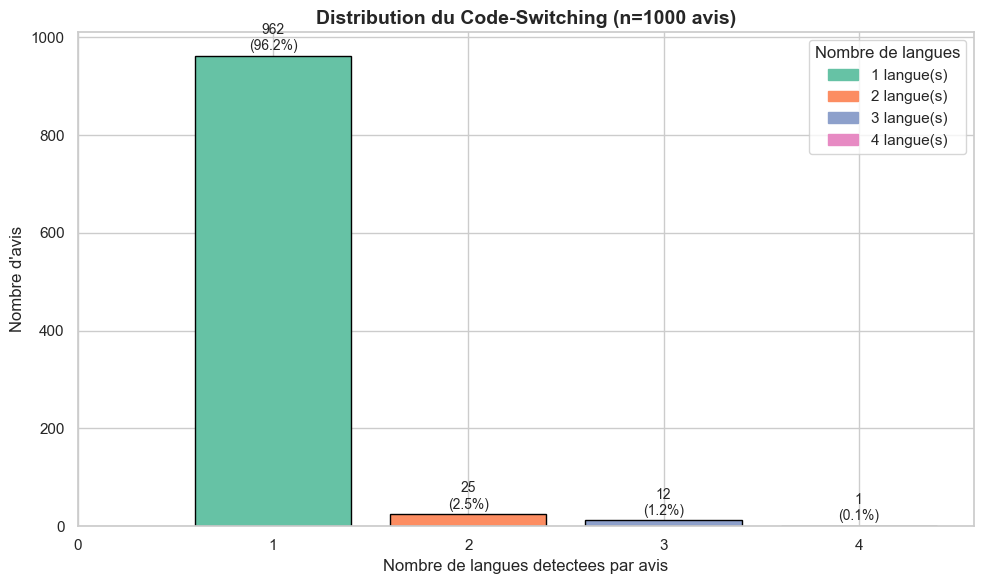


RESUME — Code-Switching :
  - Total d'avis analyses : 1000
  - Avis monolingues (1 langue) : 962 (96.2%)
  - Avis bilingues (2 langues) : 25 (2.5%)
  - Avis multilingues (3+ langues) : 13 (1.3%)

Exemples de reviews avec melange de langues :

1. [3 langues] ثمن Bon Rapport على الجودة، ولكن ليس على القمة :) 
   -> AR: 56%, FR: 22%, UG: 22%

2. [2 langues] وبالنسبة للثمن، فإنه يفعل ذلك.
   -> AR: 80%, UK: 20%

3. [2 langues] وبالنسبة للثمن، فإنه يفعل ذلك.
   -> AR: 80%, UK: 20%

4. [2 langues] وبالنسبة للثمن، فإنه يفعل ذلك.
   -> AR: 80%, UK: 20%

5. [2 langues] إنتاج صحيح للأسعار ولكن صاخب
   -> AR: 80%, ES: 20%


In [24]:
# =============================================================================
# 1. CHARGER LE MODELE FASTTEXT (pre-entraine)
# =============================================================================
# Telecharger depuis : https://fasttext.cc/docs/en/language-identification.html
# Modele : lid.176.ftz (176 langues, compresse)
import os
from matplotlib.patches import Patch

MODEL_PATH = "lid.176.ftz"
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Modele introuvable: {MODEL_PATH}")
model = fasttext.load_model(MODEL_PATH)

# =============================================================================
# 2. FONCTION : Detecter les langues dans un texte (par echantillonnage de mots)
# =============================================================================
ARABIC_VARIANTS = {'AR', 'ARZ', 'FA', 'PNB', 'PS'}

def normalize_language_label(label):
    if label in ARABIC_VARIANTS:
        return 'AR'
    return label

def detect_languages_in_text(text, min_words=5, max_words=40, dominance_threshold=0.2):
    """
    Estime le nombre de langues avec un echantillon de mots pour limiter le cout.
    Retourne le nombre de langues retenues et un dict langue -> proportion.
    """
    if pd.isna(text) or not isinstance(text, str):
        return 1, {}
    words = re.findall(r'\b\w+\b', text.lower())
    if len(words) < min_words:
        return 1, {}
    if len(words) > max_words:
        words = words[:max_words]

    labels, _probs = model.predict(words, k=1)
    lang_counts = {}
    for label_list in labels:
        if not label_list:
            continue
        label = label_list[0]
        lang = normalize_language_label(label.replace('__label__', '').upper())
        lang_counts[lang] = lang_counts.get(lang, 0) + 1
    total_words = sum(lang_counts.values())
    if total_words == 0:
        return 1, {}
    lang_props = {lang: count / total_words for lang, count in lang_counts.items()}
    significant_langs = [lang for lang, p in lang_props.items() if p >= dominance_threshold]
    if not significant_langs and lang_props:
        return 1, lang_props
    return len(significant_langs), lang_props

# =============================================================================
# 3. APPLIQUER SUR df_multi
# =============================================================================
print("Analyse du code-switching en cours...")

# Appliquer sur un echantillon si le dataset est grand (pour aller plus vite)
sample_size = min(1000, len(df_multi))  # Premier 1000 avis
df_sample = df_multi.head(sample_size).copy()

# Detecter les langues par review
df_sample['language_info'] = df_sample['text'].apply(detect_languages_in_text)
df_sample['num_languages'] = df_sample['language_info'].apply(lambda x: x[0])
df_sample['language_props'] = df_sample['language_info'].apply(lambda x: x[1])

# =============================================================================
# 4. VISUALISATION : Histogramme du nombre de langues par review
# =============================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Compter les occurrences
lang_counts = df_sample['num_languages'].value_counts().sort_index()

# Bar chart
colors = plt.cm.Set2(range(len(lang_counts)))
bars = plt.bar(lang_counts.index, lang_counts.values, color=colors, edgecolor='black')

# Ajouter les valeurs et pourcentages
total = len(df_sample)
for bar, count in zip(bars, lang_counts.values):
    pct = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

# Legende des couleurs
legend_handles = [
    Patch(color=colors[i], label=f"{lang_counts.index[i]} langue(s)")
    for i in range(len(lang_counts))
 ]
plt.legend(handles=legend_handles, title="Nombre de langues", loc='upper right')

plt.title(f"Distribution du Code-Switching (n={sample_size} avis)", 
          fontweight='bold', fontsize=14)
plt.xlabel('Nombre de langues detectees par avis')
plt.ylabel("Nombre d'avis")
plt.xticks(range(0, max(lang_counts.index)+1))
plt.tight_layout()
plt.show()

# =============================================================================
# 5. STATS DETAILLEES
# =============================================================================
print("\nRESUME — Code-Switching :")
print(f"  - Total d'avis analyses : {len(df_sample)}")
print(f"  - Avis monolingues (1 langue) : {(df_sample['num_languages']==1).sum()} ({(df_sample['num_languages']==1).mean()*100:.1f}%)")
print(f"  - Avis bilingues (2 langues) : {(df_sample['num_languages']==2).sum()} ({(df_sample['num_languages']==2).mean()*100:.1f}%)")
print(f"  - Avis multilingues (3+ langues) : {(df_sample['num_languages']>=3).sum()} ({(df_sample['num_languages']>=3).mean()*100:.1f}%)")

# Exemples de reviews avec code-switching
print("\nExemples de reviews avec melange de langues :")
examples = df_sample[df_sample['num_languages'] >= 2].head(5)
for i, (_, row) in enumerate(examples.iterrows(), 1):
    details = ', '.join(
        f"{lang}: {pct:.0%}"
        for lang, pct in sorted(row['language_props'].items(), key=lambda item: item[1], reverse=True)
    )
    print(f"\n{i}. [{row['num_languages']} langues] {row['text']}")
    print(f"   -> {details}")

Dropdown(description='Visualisation:', index=3, options=(('Répartition des notes', 'ratings'), ('Sentiment par…

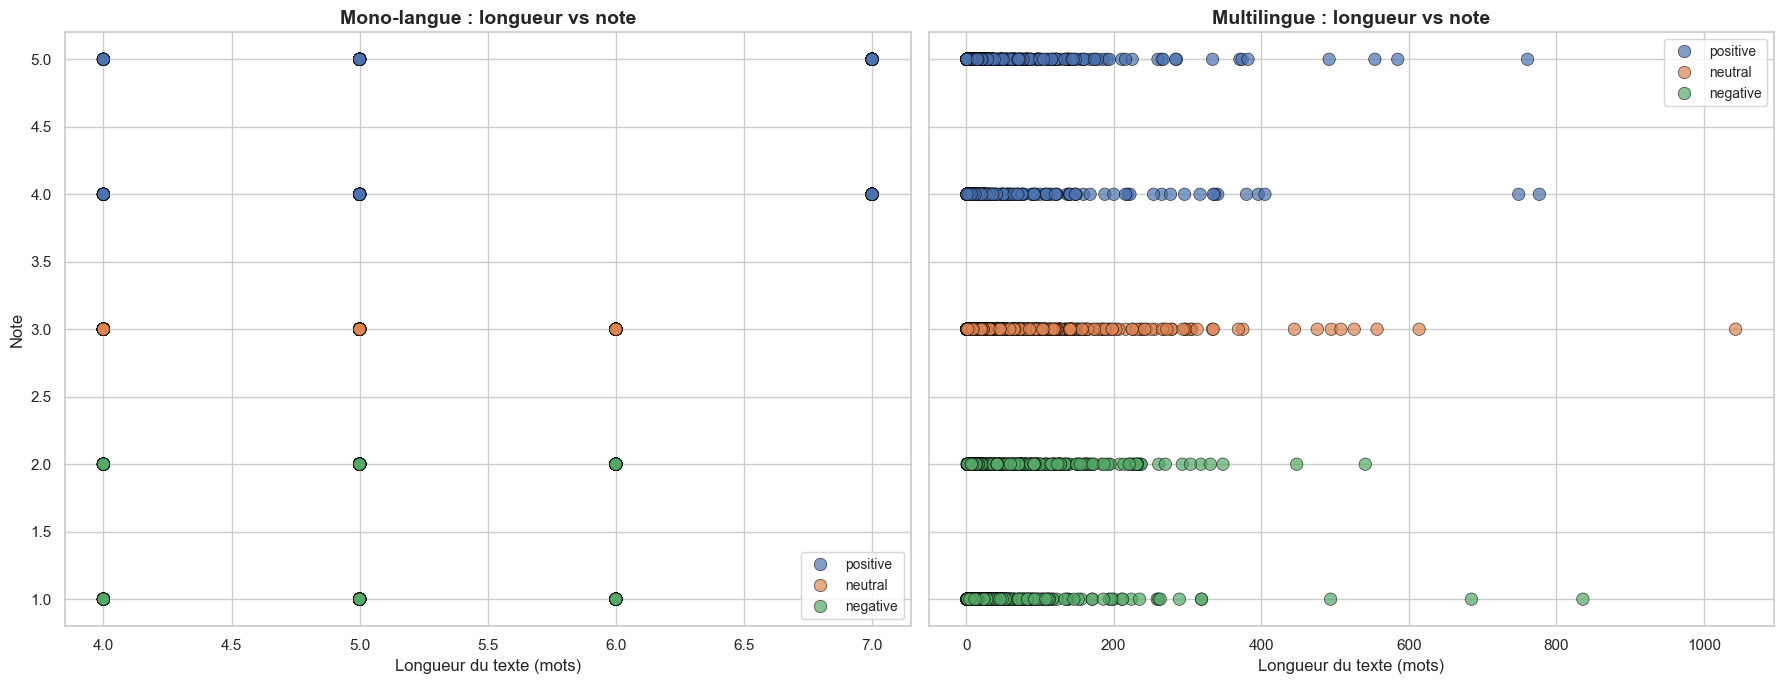

In [31]:
# =============================================================================
# 6. VISUALISATIONS SUPPLEMENTAIRES AVEC WIDGET INTERACTIF
# =============================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

# =============================================================================
# 1. FONCTIONS DE VISUALISATION
# =============================================================================

def afficher_rating_distribution():
    """Repartition des notes par dataset"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    
    sns.countplot(data=df_mono, x='rating', hue='rating', palette='Blues', edgecolor='black', legend=False, ax=axes[0], linewidth=1.5)
    axes[0].set_title('Mono-langue : repartition des notes', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Note', fontsize=12)
    axes[0].set_ylabel('Nombre d\'avis', fontsize=12)
    axes[0].tick_params(labelsize=11)
    
    sns.countplot(data=df_multi, x='rating', hue='rating', palette='Reds', edgecolor='black', legend=False, ax=axes[1], linewidth=1.5)
    axes[1].set_title('Multilingue : repartition des notes', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Note', fontsize=12)
    axes[1].set_ylabel('Nombre d\'avis', fontsize=12)
    axes[1].tick_params(labelsize=11)
    
    plt.tight_layout()
    plt.show()

def afficher_sentiment_category():
    """Sentiment par categorie de produit"""
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    for ax, df, title in [
        (axes[0], df_mono, 'Mono-langue : sentiment par categorie'),
        (axes[1], df_multi, 'Multilingue : sentiment par categorie'),
    ]:
        ct = pd.crosstab(df['product_category'], df['sentiment'], normalize='index') * 100
        sentiment_cols = [c for c in ['positive', 'neutral', 'negative'] if c in ct.columns]
        ct = ct[sentiment_cols]
        ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', width=0.85, linewidth=1.5)
        ax.set_title(title, fontweight='bold', fontsize=14)
        ax.set_xlabel('Categorie', fontsize=12)
        ax.set_ylabel('% d\'avis', fontsize=12)
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        ax.tick_params(axis='y', labelsize=11)
        ax.legend(title='Sentiment', loc='upper right', fontsize=10, title_fontsize=11)
        ax.grid(axis='y', alpha=0.25, linewidth=1.2)
    
    plt.tight_layout()
    plt.show()

def afficher_rating_language_heatmap():
    """Heatmap de la note moyenne par categorie et langue"""
    if 'language' in df_multi.columns and 'rating' in df_multi.columns:
        avg_rating = pd.pivot_table(
            df_multi,
            values='rating',
            index='product_category',
            columns='language',
            aggfunc='mean'
        )
        plt.figure(figsize=(12, 8))
        sns.heatmap(avg_rating, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=1.5, cbar_kws={'label': 'Note moyenne'}, annot_kws={'fontsize': 11})
        plt.title('Multilingue : note moyenne par categorie et langue', fontweight='bold', fontsize=14)
        plt.xlabel('Langue', fontsize=12)
        plt.ylabel('Categorie', fontsize=12)
        plt.tick_params(labelsize=11)
        plt.tight_layout()
        plt.show()

def afficher_length_vs_rating():
    """Relation longueur vs note"""
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    sns.scatterplot(data=df_mono, x='length', y='rating', hue='sentiment', alpha=0.7, ax=axes[0], s=80, edgecolor='black', linewidth=0.5)
    axes[0].set_title('Mono-langue : longueur vs note', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Longueur du texte (mots)', fontsize=12)
    axes[0].set_ylabel('Note', fontsize=12)
    axes[0].tick_params(labelsize=11)
    axes[0].legend(fontsize=10, title_fontsize=11)
    
    sns.scatterplot(data=df_multi, x='length', y='rating', hue='sentiment', alpha=0.7, ax=axes[1], s=80, edgecolor='black', linewidth=0.5)
    axes[1].set_title('Multilingue : longueur vs note', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Longueur du texte (mots)', fontsize=12)
    axes[1].set_ylabel('Note', fontsize=12)
    axes[1].tick_params(labelsize=11)
    axes[1].legend(fontsize=10, title_fontsize=11)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 2. WIDGET DE SELECTION
# =============================================================================

sns.set_theme(style="whitegrid")

dropdown_viz = widgets.Dropdown(
    options=[
        ('Répartition des notes', 'ratings'),
        ('Sentiment par catégorie', 'sentiment'),
        ('Heatmap : Note × Langue', 'heatmap'),
        ('Longueur vs Note', 'length')
    ],
    value='ratings',
    description='Visualisation:',
    style={'description_width': 'initial'}
)

def on_change_viz(change):
    clear_output(wait=True)
    display(dropdown_viz)
    
    if change['new'] == 'ratings':
        afficher_rating_distribution()
    elif change['new'] == 'sentiment':
        afficher_sentiment_category()
    elif change['new'] == 'heatmap':
        afficher_rating_language_heatmap()
    elif change['new'] == 'length':
        afficher_length_vs_rating()

dropdown_viz.observe(on_change_viz, names='value')

# Afficher le menu et la première visualisation
display(dropdown_viz)
afficher_rating_distribution()